In [15]:
!pip install lifelines scikit-survival -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.datasets import load_gbsg2
from lifelines.statistics import logrank_test

df = load_gbsg2()
df.head()

,horTh,age,menostat,tsize,tgrade,pnodes,progrec,estrec,time,cens
0,no,70,Post,21,II,3,48,66,1814,1
1,yes,56,Post,12,II,7,61,77,2018,1
2,yes,58,Post,35,II,9,52,271,712,1
3,yes,59,Post,17,II,4,60,29,1807,1
4,no,73,Post,35,II,1,26,65,772,1


In [16]:
print(df.shape)
print(df['cens'].value_counts())
df.describe()

(686, 10)
cens
0    387
1    299
Name: count, dtype: int64


,age,tsize,pnodes,progrec,estrec,time,cens
count,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000
mean,53.052478,29.329446,5.010204,109.995627,96.252187,1124.489796,0.435860
std,10.120739,14.296217,5.475483,202.331552,153.083963,642.791948,0.496231
min,21.000000,3.000000,1.000000,0.000000,0.000000,8.000000,0.000000
25%,46.000000,20.000000,1.000000,7.000000,8.000000,567.750000,0.000000
50%,53.000000,25.000000,3.000000,32.500000,36.000000,1084.000000,0.000000
75%,61.000000,35.000000,7.000000,131.750000,114.000000,1684.750000,1.000000
max,80.000000,120.000000,51.000000,2380.000000,1144.000000,2659.000000,1.000000


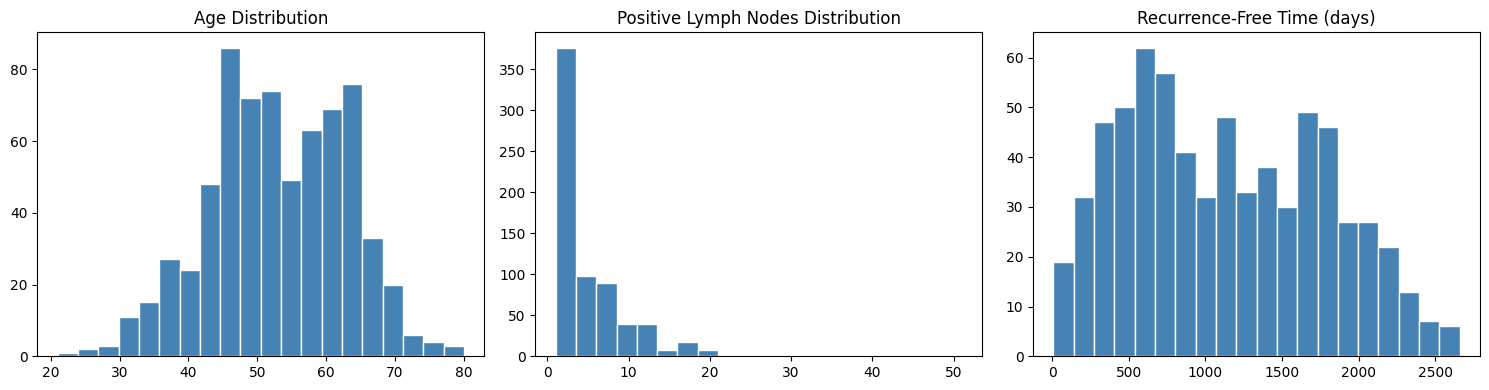

horTh
no     440
yes    246
Name: count, dtype: int64


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')

axes[1].hist(df['pnodes'], bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Positive Lymph Nodes Distribution')

axes[2].hist(df['time'], bins=20, color='steelblue', edgecolor='white')
axes[2].set_title('Recurrence-Free Time (days)')

plt.tight_layout()
plt.show()

print(df['horTh'].value_counts())

In [17]:
df.isnull().sum()

,0
horTh,0
age,0
menostat,0
tsize,0
tgrade,0
pnodes,0
progrec,0
estrec,0
time,0
cens,0


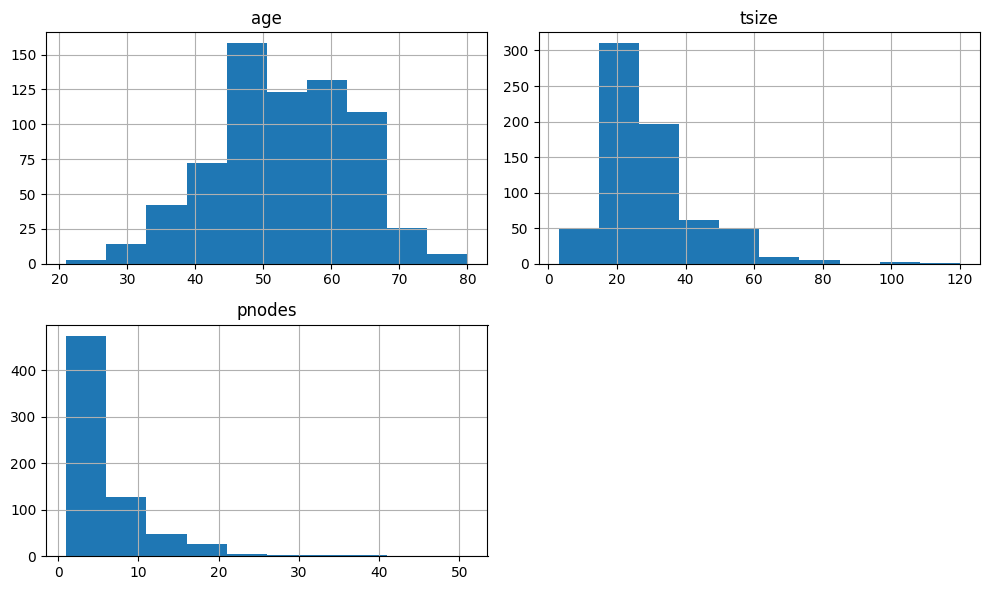

In [18]:
df.isnull().sum()
df[['age', 'tsize', 'pnodes']].hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

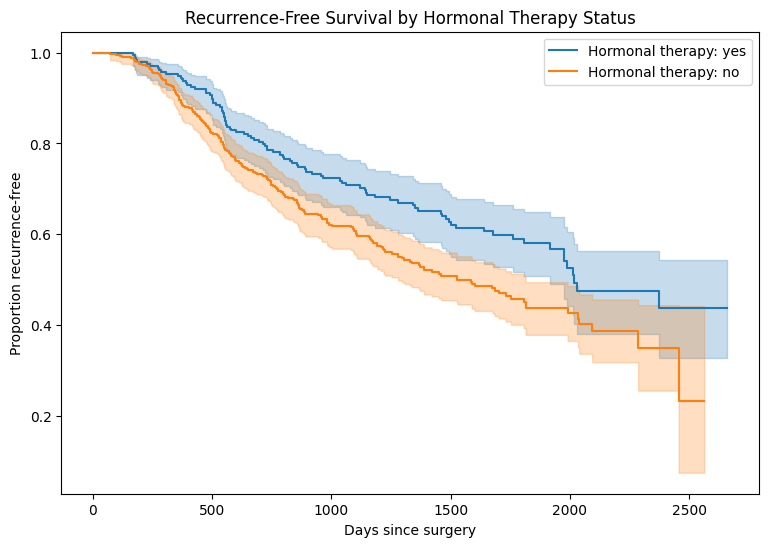

log-rank p-value: 0.0034


In [19]:
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(9, 6))

for group in ['yes', 'no']:
    mask = df['horTh'] == group
    kmf.fit(df.loc[mask, 'time'], df.loc[mask, 'cens'], label=f'Hormonal therapy: {group}')
    kmf.plot_survival_function(ax=ax)

ax.set_title('Recurrence-Free Survival by Hormonal Therapy Status')
ax.set_xlabel('Days since surgery')
ax.set_ylabel('Proportion recurrence-free')
plt.show()

# log-rank
group_yes = df[df['horTh'] == 'yes']
group_no = df[df['horTh'] == 'no']
result = logrank_test(group_yes['time'], group_no['time'], group_yes['cens'], group_no['cens'])
print(f"log-rank p-value: {result.p_value:.4f}")

In [20]:
cox_df = df.copy()
cox_df['horTh_yes'] = (cox_df['horTh'] == 'yes').astype(int)
cox_df['tgrade_num'] = cox_df['tgrade'].map({'I': 1, 'II': 2, 'III': 3})

cph = CoxPHFitter()
cph.fit(
    cox_df[['time', 'cens', 'horTh_yes', 'age', 'tgrade_num', 'pnodes', 'tsize']],
    duration_col='time',
    event_col='cens'
)
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'time'
                event col = 'cens'
      baseline estimation = breslow
   number of observations = 686
number of events observed = 299
   partial log-likelihood = -1749.75
         time fit was run = 2026-07-03 18:24:21 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
horTh_yes  -0.33      0.72      0.13           -0.59           -0.08                0.56                0.92
age         0.00      1.00      0.01           -0.01            0.01                0.99                1.01
tgrade_num  0.39      1.48      0.10            0.19            0.59                1.21                1.81
pnodes      0.05      1.05      0.01            0.04            0.07                1.04                1.07
tsize       0.01      1.01      0.00           -0.00            0.01                1.00                1.01

            cmp to     z      p  -log2(p)
covariate                                
horTh_yes     0.00 -2.59   0.01      6.72
age           0.00  0.06   0.95      0.07
tgrade_num    0.00  3.83 <0.005     12.93
pnodes        0.00  7.02 <0.005     38.75
tsize         0.00  1.75   0.08      3.63
---
Concordance = 0.66
Partial AIC = 3509.50
log-likelihood ratio test = 76.71 on 5 df
-log2(p) of ll-ratio test = 47.79

In [21]:
cph.check_assumptions(
    cox_df[['time', 'cens', 'horTh_yes', 'age', 'tgrade_num', 'pnodes', 'tsize']],
    p_value_threshold=0.05
)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'age' failed the non-proportional test: p-value is 0.0034.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'tgrade_num' failed the non-proportional test: p-value is 0.0027.

   Advice: with so few unique values (only 3), you can include `strata=['tgrade_num', ...]` in the
call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedo

[]

In [22]:
cox_df['age_group'] = pd.cut(cox_df['age'], bins=[0, 45, 55, 65, 100], labels=['<=45', '46-55', '56-65', '65+'])

cph_stratified = CoxPHFitter()
cph_stratified.fit(
    cox_df[['time', 'cens', 'horTh_yes', 'pnodes', 'tsize', 'age_group', 'tgrade_num']],
    duration_col='time',
    event_col='cens',
    strata=['age_group', 'tgrade_num']
)
cph_stratified.print_summary()

/usr/local/lib/python3.12/dist-packages/lifelines/fitters/__init__.py:1284: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, df_ in df.groupby(strata):
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, stratified_X in X.groupby(self.strata):
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

<lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'time'
                event col = 'cens'
                   strata = ['age_group', 'tgrade_num']
      baseline estimation = breslow
   number of observations = 686
number of events observed = 299
   partial log-likelihood = -1135.16
         time fit was run = 2026-07-03 18:24:21 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
horTh_yes -0.37      0.69      0.13           -0.63           -0.11                0.53                0.89
pnodes     0.05      1.05      0.01            0.03            0.06                1.03                1.07
tsize      0.01      1.01      0.00            0.00            0.02                1.00                1.02

           cmp to     z      p  -log2(p)
covariate                               
horTh_yes    0.00 -2.83 <0.005      7.75
pnodes       0.00  6.37 <0.005     32.34
tsize        0.00  2.02   0.04      4.52
---
Concordance = 0.64
Partial AIC = 2276.31
log-likelihood ratio test = 54.22 on 3 df
-log2(p) of ll-ratio test = 36.53

In [23]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
from lifelines.utils import concordance_index

features = ['horTh_yes', 'age', 'tgrade_num', 'pnodes', 'tsize']
X = cox_df[features]
y_time = cox_df['time']
y_event = cox_df['cens']

X_train, X_test, time_train, time_test, event_train, event_test = train_test_split(
    X, y_time, y_event, test_size=0.25, random_state=42
)

# Cox模型在测试集上的表现
cph_eval = CoxPHFitter()
train_df = X_train.copy()
train_df['time'] = time_train
train_df['cens'] = event_train
cph_eval.fit(train_df, duration_col='time', event_col='cens')
cox_score = cph_eval.score(pd.concat([X_test, time_test, event_test], axis=1), scoring_method="concordance_index")

# Random Survival Forest的表现
y_train_struct = Surv.from_arrays(event=event_train.astype(bool), time=time_train)
y_test_struct = Surv.from_arrays(event=event_test.astype(bool), time=time_test)

rsf = RandomSurvivalForest(n_estimators=200, random_state=42)
rsf.fit(X_train, y_train_struct)
rsf_score = rsf.score(X_test, y_test_struct)

print(f"Cox PH concordance index: {cox_score:.3f}")
print(f"Random Survival Forest concordance index: {rsf_score:.3f}")

Cox PH concordance index: 0.673
Random Survival Forest concordance index: 0.650


In [24]:
train_df_strat = X_train.copy()
train_df_strat['time'] = time_train
train_df_strat['cens'] = event_train
train_df_strat['age_group'] = pd.cut(train_df_strat['age'], bins=[0, 45, 55, 65, 100], labels=['<=45', '46-55', '56-65', '65+'])

cph_strat_eval = CoxPHFitter()
cph_strat_eval.fit(
    train_df_strat[['time', 'cens', 'horTh_yes', 'pnodes', 'tsize', 'age_group', 'tgrade_num']],
    duration_col='time', event_col='cens',
    strata=['age_group', 'tgrade_num']
)

test_df_strat = X_test.copy()
test_df_strat['time'] = time_test
test_df_strat['cens'] = event_test
test_df_strat['age_group'] = pd.cut(test_df_strat['age'], bins=[0, 45, 55, 65, 100], labels=['<=45', '46-55', '56-65', '65+'])

cox_strat_score = cph_strat_eval.score(test_df_strat, scoring_method="concordance_index")
print(f"Stratified Cox concordance index: {cox_strat_score:.3f}")
print(f"Original Cox concordance index: {cox_score:.3f}")
print(f"Random Survival Forest concordance index: {rsf_score:.3f}")

/usr/local/lib/python3.12/dist-packages/lifelines/fitters/__init__.py:1284: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, df_ in df.groupby(strata):
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, stratified_X in X.groupby(self.strata):
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

Stratified Cox concordance index: 0.714
Original Cox concordance index: 0.673
Random Survival Forest concordance index: 0.650


/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:2538: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, stratum_predicted_partial_hazards_ in predicted_partial_hazards_.groupby(self.strata):
/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


      feature  importance_mean  importance_std
3      pnodes         0.139862        0.031647
2  tgrade_num         0.010018        0.011148
1         age         0.002768        0.013577
0   horTh_yes        -0.001005        0.008331
4       tsize        -0.015887        0.012130


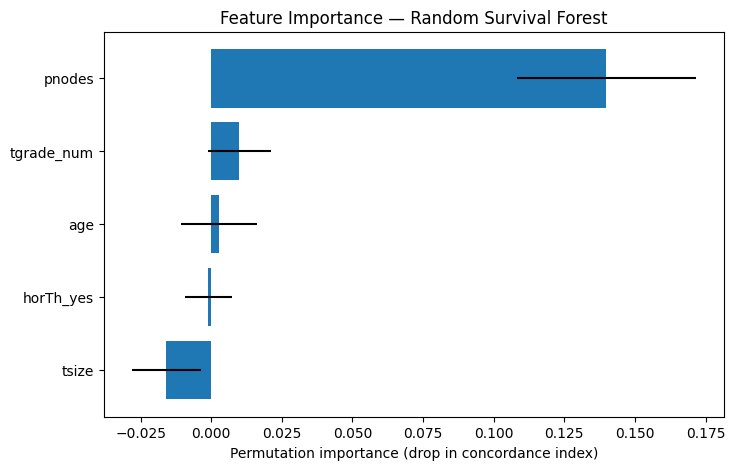

In [26]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rsf, X_test, y_test_struct,
    n_repeats=15,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': features,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values('importance_mean', ascending=False)

print(importance_df)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'], importance_df['importance_mean'], xerr=importance_df['importance_std'])
plt.xlabel('Permutation importance (drop in concordance index)')
plt.title('Feature Importance — Random Survival Forest')
plt.gca().invert_yaxis()
plt.show()

## Summary

Kaplan-Meier curves showed a visible separation in recurrence-free survival between
patients who received hormonal therapy and those who didn't (log-rank p = 0.0034).

The initial Cox model showed both `age` and `tgrade` violated the proportional hazards
assumption (p = 0.0034 and p = 0.0027), meaning their effect on risk wasn't constant
over time. After stratifying on both variables, the corrected model's concordance
index improved from 0.673 to 0.714 — confirming the correction wasn't just a
formality, it actually mattered.

In the corrected model, hormonal therapy remained a strong, independent predictor
(HR = 0.69, p < 0.005) — patients on hormonal therapy had roughly 31% lower
recurrence risk after controlling for nodal involvement, tumor size, age, and grade.

Interestingly, this contradicts the Random Survival Forest's permutation importance,
which ranked `horTh_yes` as contributing almost nothing to prediction. Since RSF's
own concordance index (0.650) was lower than the corrected Cox model's (0.714),
this is likely because RSF underweights a moderate, fairly linear effect like this
one — a reminder that different models can disagree about a variable's importance
even when both are technically valid, and that concordance index alone doesn't tell
you which variable-level conclusions to trust more.

Note: the two treatment groups aren't perfectly balanced (440 no-therapy vs 246
hormonal-therapy patients), but both are large enough that this isn't a concern
for the statistical tests used here.